In [54]:
import torch
import torch.nn as nn
import math
import pandas as pd
import numpy as np
import copy
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix, cohen_kappa_score
import seaborn as sns
import matplotlib.pyplot as plt

In [55]:
# Configuration du notebook
EXTRA_COLS  = ['clim_precip', 'clim_temp', 'soil_texture', 'topo_elevation', 'topo_slope']
IN_CHANNELS = 15
MODEL_NAME  = 'model_california_all'

In [56]:
class CNNSubmodule(nn.Module):
    def __init__(self, in_channels): 
        super(CNNSubmodule, self).__init__()
        #mid_channels = in_channels * 2 # On remet l'expansion forte
        mid_channels = in_channels 
        self.conv1 = nn.Conv1d(in_channels, mid_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(mid_channels)
        self.conv2 = nn.Conv1d(mid_channels, mid_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(mid_channels)
        self.conv3 = nn.Conv1d(mid_channels, in_channels, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(in_channels)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.transpose(1, 2)
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out = self.relu(out + identity) # Résidu
        return out.transpose(1, 2)

class ALPE(nn.Module):
    def __init__(self, d_model=10, max_len=36):
        super(ALPE, self).__init__()
        self.d_model = d_model
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        # Gérer le cas où d_model est impair
        pe[:, 1::2] = torch.cos(position * div_term[:d_model//2])
        self.register_buffer('pe', pe.unsqueeze(0))
        self.conv1d = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1)
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.eca_conv = nn.Conv1d(1, 1, kernel_size=3, padding=1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def eca(self, x):
        y = self.avg_pool(x)
        y = self.eca_conv(y.transpose(-1, -2)).transpose(-1, -2)
        y = self.sigmoid(y)
        return x * y.expand_as(x)

    def forward(self, x, input2_mask):
        b, t, c = x.size()
        pos_vector = self.pe[:, :t, :].clone().repeat(b, 1, 1)
        pos_vector = pos_vector * input2_mask
        pos_vector = pos_vector.transpose(1, 2)
        pos_vector = self.conv1d(pos_vector)
        pos_vector = self.eca(pos_vector)
        return pos_vector.transpose(1, 2)


class TransformerSubmodule(nn.Module):
    def __init__(self, d_model, nhead=None, dim_feedforward=512, use_alpe=False): # Augmenté à 512
        super(TransformerSubmodule, self).__init__()
        self.use_alpe = use_alpe
        
        # On rend le calcul du nhead plus flexible pour accepter plus de têtes
        if nhead is None:
            for n in [8, 5, 4, 2, 1]: # Ajout du 8 si d_model est 40 ou 80
                if d_model % n == 0:
                    nhead = n
                    break
        
        if self.use_alpe:
            self.alpe = ALPE(d_model=d_model)
            
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=dim_feedforward, # Plus de neurones ici
            dropout=0.3, # Un peu de dropout interne pour la stabilité
            batch_first=True
        )
        # On peut aussi passer num_layers à 2 pour doubler la réflexion
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)
    def forward(self, x, input2_mask=None):
        if self.use_alpe and input2_mask is not None:
            pos_info = self.alpe(x, input2_mask)
            x = x + pos_info
        out = self.transformer_encoder(x)
        return out

class MCTNet(nn.Module):
    def __init__(self, num_classes, in_channels=15):
        super(MCTNet, self).__init__()
        c1, c2, c3, c4 = in_channels, in_channels*2, in_channels*4, in_channels*8

        # Étages
        self.cnn1, self.trans1 = CNNSubmodule(c1), TransformerSubmodule(c1, nhead=5, use_alpe=True)
        self.pool1 = nn.MaxPool1d(2) # 36 -> 18
        self.cnn2, self.trans2 = CNNSubmodule(c2), TransformerSubmodule(c2, nhead=6)
        self.pool2 = nn.MaxPool1d(2) # 18 -> 9

        self.cnn3, self.trans3 = CNNSubmodule(c3), TransformerSubmodule(c3, nhead=10)
        # PAS DE POOL3 ICI
        self.cnn4, self.trans4 = CNNSubmodule(c4), TransformerSubmodule(c4, nhead=12)

        self.global_pool = nn.AdaptiveMaxPool1d(1)
        self.mlp = nn.Sequential(
            nn.Linear(c4 * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.3), 
            nn.Linear(128, num_classes)
        )

    def forward(self, x, mask):
        # Étage 1 & 2
        x = self.pool1(torch.cat([self.cnn1(x), self.trans1(x, mask)], -1).transpose(1,2)).transpose(1,2)
        x = self.pool2(torch.cat([self.cnn2(x), self.trans2(x)], -1).transpose(1,2)).transpose(1,2)

        # Étage 3 & 4 (Haute résolution : 9 points)
        x = torch.cat([self.cnn3(x), self.trans3(x)], -1)
        x = torch.cat([self.cnn4(x), self.trans4(x)], -1)

        x = self.global_pool(x.transpose(1, 2)).squeeze(-1)
        return self.mlp(x)

In [57]:
df_cali = pd.read_csv('../data/california_preprocessed_v2.csv')
df_cali.head()

,d0_B2,d0_B3,d0_B4,d0_B5,d0_B6,d0_B7,d0_B8,d0_B8A,d0_B11,d0_B12,...,d35_B8A,d35_B11,d35_B12,clim_precip,clim_temp,soil_texture,topo_elevation,topo_slope,cropland,target_class
0,0.04820,0.06105,0.06470,0.09330,0.13855,0.15165,0.17355,0.17550,0.21355,0.15090,...,0.00000,0.00000,0.00000,0.397416,-0.651279,0.525297,-0.433458,-0.330163,76,4
1,0.06170,0.08805,0.10080,0.13435,0.19605,0.21765,0.23495,0.23375,0.27285,0.23035,...,0.00000,0.00000,0.00000,0.132386,1.235055,0.525297,-0.583178,-0.612763,36,2
2,0.04420,0.06350,0.10130,0.11880,0.13210,0.15020,0.17570,0.18160,0.24420,0.20890,...,0.41005,0.29705,0.24475,-1.015309,0.950606,0.525297,-0.266627,-0.443951,69,0
3,0.08615,0.10970,0.14635,0.16965,0.18835,0.20460,0.22510,0.23185,0.33110,0.25865,...,0.00000,0.00000,0.00000,-1.032278,1.098399,0.525297,-0.561790,-0.781662,36,2
4,0.24455,0.24090,0.25870,0.27515,0.27545,0.28775,0.30590,0.30050,0.38235,0.33175,...,0.00000,0.00000,0.00000,0.049402,1.259696,1.146951,-0.608845,-0.512391,36,2


In [58]:
mapping = {69: 0, 3: 1, 36: 2, 75: 3, 76: 4, 176: 5}
def map_classes(val):
    return mapping.get(val, 5)

df_cali['target_class'] = df_cali['cropland'].apply(map_classes)

targets = {0: 2054, 1: 2037, 2: 974, 3: 783, 4: 640, 5: 3512}
sampled_dfs = []
for class_id, count in targets.items():
    sub_df = df_cali[df_cali['target_class'] == class_id]
    sampled_dfs.append(sub_df.sample(n=min(len(sub_df), count), random_state=42))

df_cali_final = pd.concat(sampled_dfs).sample(frac=1, random_state=42)
print(df_cali_final['target_class'].value_counts())

target_class
5    3512
0    2054
1    2037
2     974
3     783
4     640
Name: count, dtype: int64


In [59]:
print(df_cali['target_class'].value_counts())
print(f"Total : {len(df_cali)}")

target_class
5    3512
0    2054
1    2037
2     974
3     783
4     640
Name: count, dtype: int64
Total : 10000


In [60]:
def prepare_mctnet_data(df, extra_cols=None):
    BANDS = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
    ordered_cols = [f'd{i}_{band}' for i in range(36) for band in BANDS]
    x_spectral = torch.tensor(df[ordered_cols].values, dtype=torch.float32).view(-1, 36, 10)
    if extra_cols and len(extra_cols) > 0:
        x_extra = torch.tensor(df[extra_cols].values, dtype=torch.float32)
        x_extra_expanded = x_extra.unsqueeze(1).expand(-1, 36, -1)
        x_final = torch.cat([x_spectral, x_extra_expanded], dim=-1)
    else:
        x_final = x_spectral
    mask = (x_spectral > 0).all(dim=-1, keepdim=True).float()
    y = torch.tensor(df['target_class'].values, dtype=torch.long)
    return x_final, mask, y

x_cal, mask_cal, y_cal = prepare_mctnet_data(df_cali_final, extra_cols=EXTRA_COLS)
print(f'Shape X: {x_cal.shape}, Mask: {mask_cal.shape}, Y: {y_cal.shape}')

Shape X: torch.Size([10000, 36, 15]), Mask: torch.Size([10000, 36, 1]), Y: torch.Size([10000])


In [61]:
x_train, x_temp, m_train, m_temp, y_train, y_temp = train_test_split(
    x_cal, mask_cal, y_cal, test_size=0.18, stratify=y_cal, random_state=96
)
x_val, x_test, m_val, m_test, y_val, y_test = train_test_split(
    x_temp, m_temp, y_temp, test_size=0.8, stratify=y_temp, random_state=96
)

train_loader = DataLoader(TensorDataset(x_train, m_train, y_train), batch_size=256, shuffle=True)
val_loader   = DataLoader(TensorDataset(x_val,   m_val,   y_val),   batch_size=256)
test_loader  = DataLoader(TensorDataset(x_test,  m_test,  y_test),  batch_size=256)

print(f'Train={len(y_train)}, Val={len(y_val)}, Test={len(y_test)}')

Train=8200, Val=360, Test=1440


In [62]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
epochs = 30
best_f1 = 0.0
print(f'Device utilisé : {device}')

model = MCTNet(num_classes=6, in_channels=IN_CHANNELS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()
best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(epochs):
    model.train()
    train_loss = 0
    pbar = tqdm(train_loader, desc=f'Époque {epoch+1}/{epochs}', unit='batch')
    for b_x, b_mask, b_y in pbar:
        b_x, b_mask, b_y = b_x.to(device), b_mask.to(device), b_y.to(device)
        optimizer.zero_grad()
        outputs = model(b_x, b_mask)
        loss = criterion(outputs, b_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    model.eval()
    val_preds, val_targets = [], []
    val_loss = 0
    with torch.no_grad():
        for b_x, b_mask, b_y in val_loader:
            b_x, b_mask, b_y = b_x.to(device), b_mask.to(device), b_y.to(device)
            outputs = model(b_x, b_mask)
            val_loss += criterion(outputs, b_y).item()
            _, predicted = torch.max(outputs, 1)
            val_preds.extend(predicted.cpu().numpy())
            val_targets.extend(b_y.cpu().numpy())

    precision, recall, f1, _ = precision_recall_fscore_support(
        val_targets, val_preds, average='macro', zero_division=0
    )
    val_acc = 100 * np.sum(np.array(val_preds) == np.array(val_targets)) / len(val_targets)
    print(f'\n[Validation] Loss: {val_loss/len(val_loader):.4f} | Acc: {val_acc:.2f}%')
    print(f'[Scores] Precision: {precision:.4f} | Recall: {recall:.4f} | F1-Score: {f1:.4f}\n')

    if f1 > best_f1:
        best_f1 = f1
        best_model_state = copy.deepcopy(model.state_dict())
        print(f'Meilleur modèle mis à jour (F1: {best_f1:.4f})')

model.load_state_dict(best_model_state)
print(f'\nEntraînement fini. Meilleur F1: {best_f1:.4f}')

/tmp/ipykernel_6275/3856429598.py:78: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)


Device utilisé : cuda


Époque 1/30: 100%|██████████| 33/33 [00:01<00:00, 32.19batch/s, loss=0.7903]



[Validation] Loss: 0.5067 | Acc: 79.17%
[Scores] Precision: 0.7115 | Recall: 0.7112 | F1-Score: 0.7047

Meilleur modèle mis à jour (F1: 0.7047)


Époque 2/30: 100%|██████████| 33/33 [00:00<00:00, 51.12batch/s, loss=0.3362]


...


[Validation] Loss: 0.2098 | Acc: 92.50%
[Scores] Precision: 0.9109 | Recall: 0.8845 | F1-Score: 0.8948

Meilleur modèle mis à jour (F1: 0.8948)


Époque 29/30: 100%|██████████| 33/33 [00:00<00:00, 50.14batch/s, loss=0.0211]



[Validation] Loss: 0.2130 | Acc: 91.94%
[Scores] Precision: 0.8987 | Recall: 0.8771 | F1-Score: 0.8854



Époque 30/30: 100%|██████████| 33/33 [00:00<00:00, 50.62batch/s, loss=0.0823]



[Validation] Loss: 0.2477 | Acc: 92.22%
[Scores] Precision: 0.8869 | Recall: 0.8937 | F1-Score: 0.8889


Entraînement fini. Meilleur F1: 0.8948


In [63]:
torch.save(model.state_dict(), f'./models/model_california_all.pth')
print('Modèle sauvegardé : model_california_all.pth')

Modèle sauvegardé : model_california_all.pth


=== California — model_california_all ===
OA    : 0.8993
Kappa : 0.8697
              precision    recall  f1-score   support

      Grapes       0.87      0.82      0.85       296
        Rice       0.97      0.99      0.98       293
     Alfalfa       0.78      0.88      0.83       140
     Almonds       0.76      0.65      0.70       113
  Pistachios       0.77      0.79      0.78        92
      Others       0.96      0.97      0.96       506

    accuracy                           0.90      1440
   macro avg       0.85      0.85      0.85      1440
weighted avg       0.90      0.90      0.90      1440



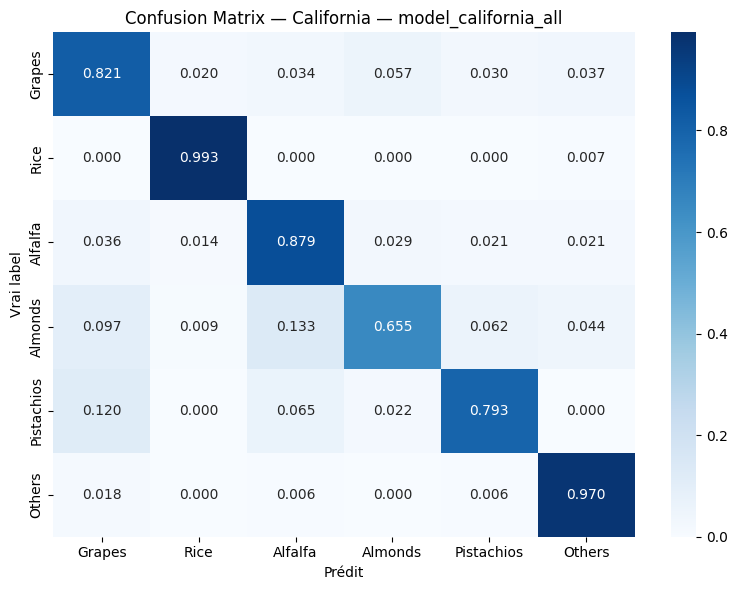

In [64]:
classes_ca = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']

def evaluate_on_test(model, test_loader, class_names, title):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for b_x, b_mask, b_y in test_loader:
            b_x, b_mask, b_y = b_x.to(device), b_mask.to(device), b_y.to(device)
            outputs = model(b_x, b_mask)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(b_y.cpu().numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    oa    = (all_preds == all_labels).mean()
    kappa = cohen_kappa_score(all_labels, all_preds)
    print(f'=== {title} ===')
    print(f'OA    : {oa:.4f}')
    print(f'Kappa : {kappa:.4f}')
    print(classification_report(all_labels, all_preds, target_names=class_names))
    cm = confusion_matrix(all_labels, all_preds, normalize='true')
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='.3f', xticklabels=class_names,
                yticklabels=class_names, cmap='Blues')
    plt.title(f'Confusion Matrix — {title}')
    plt.ylabel('Vrai label')
    plt.xlabel('Prédit')
    plt.tight_layout()
    plt.savefig(f'./figs/{MODEL_NAME}_confusion_matrix.png', dpi=150)
    plt.show()

evaluate_on_test(model, test_loader, classes_ca, 'California — model_california_all')